In [14]:
# IMPORT LIBRARIES & LOAD DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Matikan warning pandas
pd.options.mode.chained_assignment = None

df = pd.read_csv('Agriculture_price_dataset.csv')

print("Data berhasil dimuat!")
print(f"Total baris dan kolom: {df.shape}")
display(df.head(3))

Data berhasil dimuat!
Total baris dan kolom: (737392, 10)


,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023


In [15]:
# FEATURE ENGINEERING (DATETIME)

df['Price Date'] = pd.to_datetime(df['Price Date'])

# Ekstrak Bulan dan Tahun sebagai fitur numerik
df['Month'] = df['Price Date'].dt.month
df['Year'] = df['Price Date'].dt.year

print("Fitur Bulan dan Tahun berhasil diekstrak.")
display(df[['Price Date', 'Month', 'Year']].head(3))

Fitur Bulan dan Tahun berhasil diekstrak.


,Price Date,Month,Year
0,2023-06-06,6,2023
1,2023-06-06,6,2023
2,2023-06-06,6,2023


Jumlah baris sebelum dibersihkan: 737392
Jumlah baris setelah dibersihkan: 737392


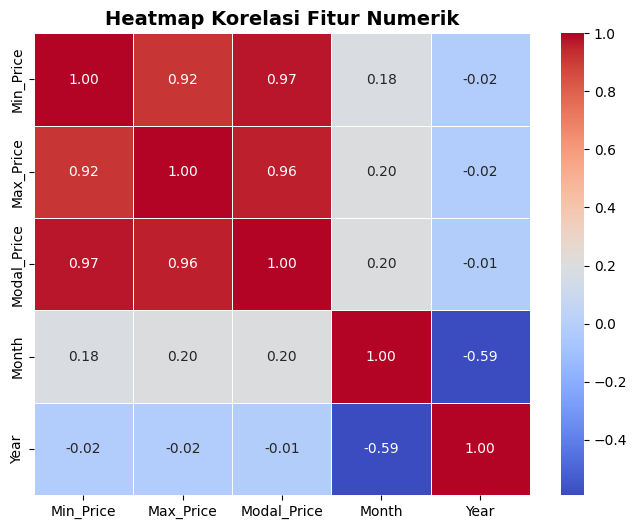

In [21]:
# CELL TAMBAHAN 1: HANDLING MISSING VALUES & EDA

print(f"Jumlah baris sebelum dibersihkan: {df.shape[0]}")
df = df.dropna()
print(f"Jumlah baris setelah dibersihkan: {df.shape[0]}")

# Heatmap Korelasi

plt.figure(figsize=(8, 6))

korelasi = df.corr(numeric_only=True)

sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.show()

In [17]:
# DATA CLEANING & ONE-HOT ENCODING

# Membuang kolom yang membuat kebocoran data dan data yang sangat spesifik
kolom_drop = ['Min_Price', 'Max_Price', 'Price Date', 'Market Name', 'District Name']
df_clean = df.drop(columns=kolom_drop)

# Fitur kategorikal yang ingin diubah menjadi angka
fitur_kategori = ['STATE', 'Commodity', 'Variety', 'Grade']

# One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=fitur_kategori, drop_first=True)

# Target (y) dan Fitur (X)
X = df_encoded.drop('Modal_Price', axis=1)
y = df_encoded['Modal_Price']

print(f"Data siap dilatih. Jumlah fitur setelah encoding: {X.shape[1]} kolom.")
display(X.head(3))

Data siap dilatih. Jumlah fitur setelah encoding: 134 kolom.


,Month,Year,STATE_Andhra Pradesh,STATE_Assam,STATE_Bihar,STATE_Chandigarh,STATE_Chattisgarh,STATE_Chhattisgarh,STATE_Delhi,STATE_Gao,...,Variety_Telagi,Variety_Tomato,Variety_WH-542,Variety_White,Grade_Large,Grade_Local,Grade_Medium,Grade_Non-FAQ,Grade_Ref grade-1,Grade_Ref grade-2
0,6,2023,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,6,2023,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,6,2023,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [18]:
# DATA SPLITTING & SCALING

# Split data: 80% untuk Train, 20% untuk Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi data StandardScaler
scaler = StandardScaler()

# Fit dan transform pada data train
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Ukuran X_train: {X_train_scaled.shape}")
print(f"Ukuran X_test: {X_test_scaled.shape}")

Ukuran X_train: (589913, 134)
Ukuran X_test: (147479, 134)


In [23]:
# LINEAR REGRESSION (1 FITUR)

print("==== SIMPLE LINEAR REGRESSION (SLR) ====")

X_train_slr = X_train_scaled[:, 0].reshape(-1, 1)
X_test_slr = X_test_scaled[:, 0].reshape(-1, 1)

# Melatih model SLR
slr_model = LinearRegression()
slr_model.fit(X_train_slr, y_train)

# Prediksi dan Evaluasi SLR
y_pred_slr = slr_model.predict(X_test_slr)
r2_slr = r2_score(y_test, y_pred_slr)

print(f"R-squared (R2) Score menggunakan SLR (1 Fitur): {r2_slr:.4f}")
print("Kesimpulan: R2 pada SLR biasanya sangat rendah karena harga komoditas tidak bisa diprediksi hanya dengan 1 faktor saja. Oleh karena itu, kita tingkatkan ke Multiple Linear Regression (MLR) di cell selanjutnya.")

==== SIMPLE LINEAR REGRESSION (SLR) ====
R-squared (R2) Score menggunakan SLR (1 Fitur): 0.0390
Kesimpulan: R2 pada SLR biasanya sangat rendah karena harga komoditas tidak bisa diprediksi hanya dengan 1 faktor saja. Oleh karena itu, kita tingkatkan ke Multiple Linear Regression (MLR) di cell selanjutnya.


In [24]:
# MODEL TRAINING

# Inisialisasi dan latih model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# prediksi pada data (Test Data)
y_pred = model.predict(X_test_scaled)

# Metrik Evaluasi
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("==== HASIL MULTIPLE LINEAR REGRESSION ====")
print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Root Mean Squared Error   : {rmse:.2f}")
print(f"R-squared (R2) Score      : {r2:.4f}")

==== HASIL MULTIPLE LINEAR REGRESSION ====
Mean Absolute Error (MAE) : 726.65
Root Mean Squared Error   : 1567.39
R-squared (R2) Score      : 0.3803


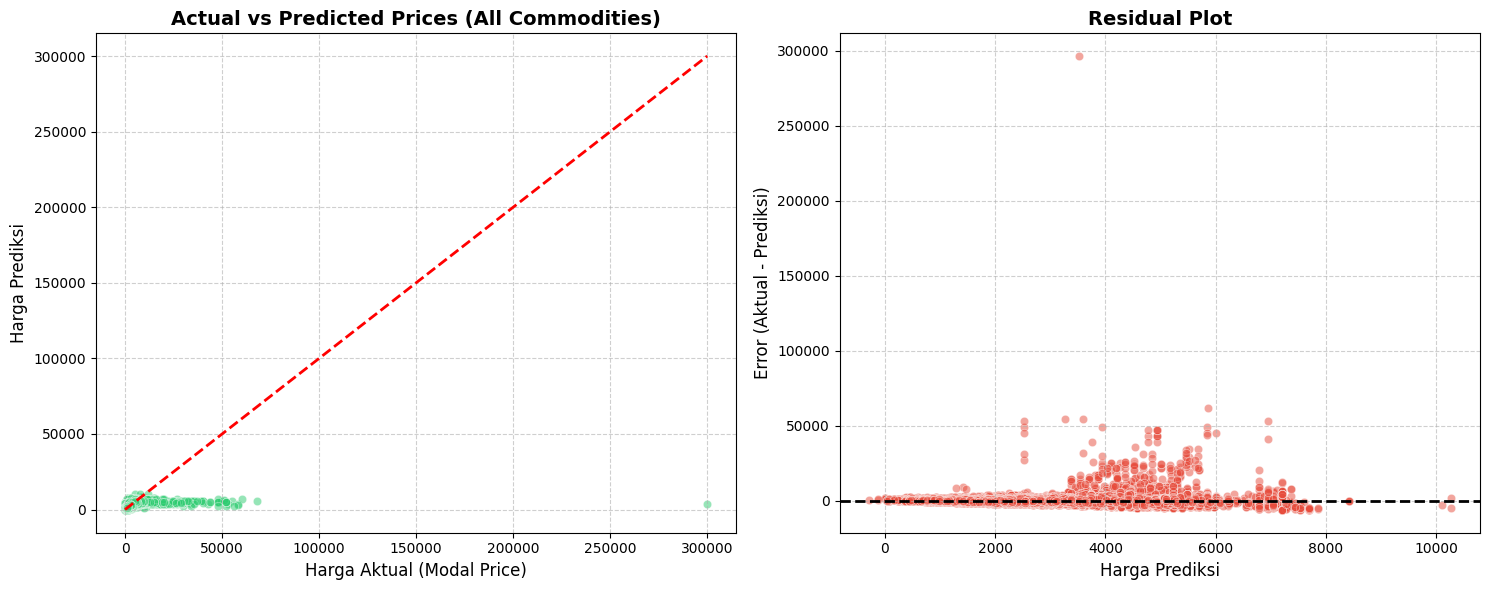

In [20]:
# VISUALISASI (ACTUAL VS PREDICTED & RESIDUALS)

plt.figure(figsize=(15, 6))

# Aktual vs Prediksi
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='#2ecc71') #Hijau
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Prices (All Commodities)', fontsize=14, fontweight='bold')
plt.xlabel('Harga Aktual (Modal Price)', fontsize=12)
plt.ylabel('Harga Prediksi', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Residual Plot
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='#e74c3c') #Merah
plt.axhline(y=0, color='black', linestyle='--', lw=2)
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.xlabel('Harga Prediksi', fontsize=12)
plt.ylabel('Error (Aktual - Prediksi)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()